# 04 — Modelado (Modeling)

**Fase CRISP-DM:** Modelado.

**Produce:** el modelo de clustering elegido y la etiqueta de grupo de cada lote (`models/`, `data/processed/coffee_clustered.csv`), y una tabla comparativa (`reports/tables/`) + gráficas (`reports/figures/`).

## 4.1 Qué se hace en esta fase

Esta fase parte de la matriz estandarizada que dejó la fase 3, con los 7 atributos de catación listos para agrupar. Sobre ella hay que:

1. **Decidir si reducir con PCA** los 7 atributos antes de agrupar.
2. **Elegir cuántos grupos (`k`)** tiene sentido formar, probando de 2 a 10.
3. **Elegir el algoritmo** de agrupamiento: k-means, aglomerativo o *gaussian mixture*.
4. **Ajustar el modelo final** y guardar la etiqueta de grupo de cada lote.

## 4.2 Contexto: los algoritmos y las métricas

En este proyecto se van a comparar tres algoritmos de agrupamiento:

| Algoritmo | Idea | Supuestos |
|---|---|---|
| **K-means** | Coloca `k` centros y asigna cada lote al más cercano, luego mueve los centros al promedio de su grupo y repite hasta que dejan de moverse. | Espera grupos más o menos redondos y de tamaño parecido. Es rápido y simple. |
| **Aglomerativo (jerárquico)** | Empieza con cada lote como su propio grupo y va uniendo los dos grupos más cercanos, uno por paso, hasta quedar en `k`. | No asume una forma particular para los grupos. Es más lento y produce un árbol (dendrograma). |
| **Gaussian Mixture (GMM)** | Asume que los datos vienen de `k` distribuciones normales y estima, para cada lote, la probabilidad de pertenecer a cada una. | Es más flexible que k-means: admite grupos alargados y de distinto tamaño. |

Como no hay una etiqueta verdadera contra la cual comparar, para decidir qué tan bueno es un agrupamiento se usan métricas internas, que solo miran la forma de los grupos:

| Métrica | Rango | Mejor valor | Qué mide |
|---|---|---|---|
| **Coeficiente de silueta** | −1 a 1 | más alto | Para cada lote, qué tan cerca está de su propio grupo frente al grupo vecino más cercano. Un promedio alto indica grupos compactos y bien separados. Es la métrica principal. |
| **Davies-Bouldin** | ≥ 0 | más bajo | La razón entre la dispersión dentro de los grupos y la separación entre ellos. |
| **Calinski-Harabasz** | ≥ 0 | más alto | La razón entre la varianza entre grupos y la varianza dentro de los grupos. |

## 4.3 Carga de la matriz de entrada

In [40]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)

from src.config import load_config, resolve_path

%matplotlib inline
pd.set_option('display.max_columns', 30)
config = load_config()
SEED = config['project']['random_seed']
K_MIN, K_MAX = config['clustering']['k_min'], config['clustering']['k_max']
ALGOS = list(config['clustering']['algorithms'])

processed = resolve_path(config['paths']['data']['processed_dir'])
X = pd.read_csv(processed / 'clustering_input.csv')
coffee = pd.read_csv(processed / 'coffee_clean.csv')
print('Matriz de entrada:', X.shape, '| columnas:', list(X.columns))
print('Rango de k a probar:', K_MIN, 'a', K_MAX, '| algoritmos:', ALGOS)

Matriz de entrada: (1310, 7) | columnas: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Cupper.Points']
Rango de k a probar: 2 a 10 | algoritmos: ['kmeans', 'agglomerative', 'gaussian_mixture']


## 4.4 ¿Reducir con PCA?

PCA (análisis de componentes principales) combina las 7 variables correlacionadas en unos pocos componentes nuevos, ordenados de mayor a menor según la cantidad de información que aportan. Sirve, en este caso, para quitar la redundancia entre los atributos antes de agrupar.

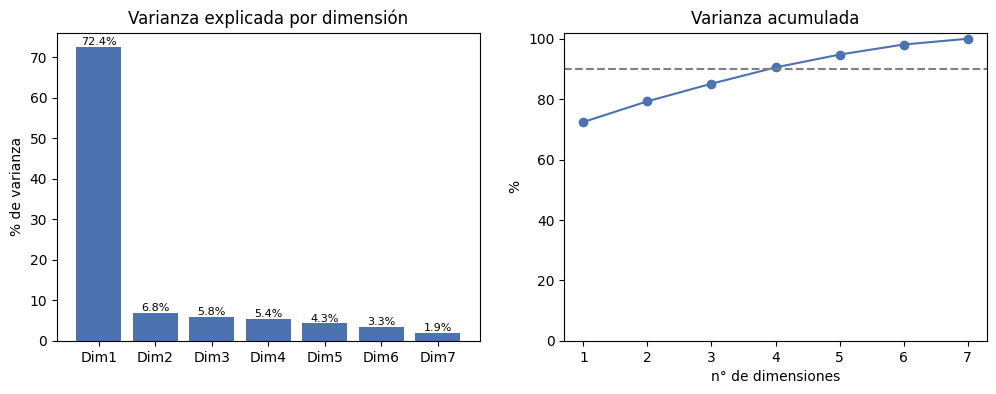

Varianza acumulada (%): [np.float64(72.4), np.float64(79.3), np.float64(85.1), np.float64(90.5), np.float64(94.8), np.float64(98.1), np.float64(100.0)]
Dimensiones para >= 90 %% de la varianza: 4
X_pca: (1310, 4)


In [41]:
FEATS = list(X.columns)
pca_full = PCA(random_state=SEED).fit(X)
var_ratio = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_ratio)
dims = [f'Dim{i+1}' for i in range(len(FEATS))]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
b = ax[0].bar(dims, var_ratio * 100, color='#4c72b0')
ax[0].bar_label(b, fmt='%.1f%%', fontsize=8)
ax[0].set_title('Varianza explicada por dimensión'); ax[0].set_ylabel('% de varianza')
ax[1].plot(range(1, len(var_cum) + 1), var_cum * 100, 'o-', color='#4c72b0')
ax[1].axhline(90, ls='--', color='gray'); ax[1].set_ylim(0, 102)
ax[1].set_title('Varianza acumulada'); ax[1].set_xlabel('n° de dimensiones'); ax[1].set_ylabel('%')
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / 'pca_scree.png', bbox_inches='tight', dpi=150)
plt.show()

n_90 = int(np.argmax(var_cum >= 0.90) + 1)
print('Varianza acumulada (%):', [round(v * 100, 1) for v in var_cum])
print(f'Dimensiones para >= 90 %% de la varianza: {n_90}')

X_pca = PCA(n_components=n_90, random_state=SEED).fit_transform(X)
print('X_pca:', X_pca.shape)

In [42]:
eig = pca_full.explained_variance_          # autovalores
comp = pca_full.components_                 # autovectores (n_dim x n_var)

# loadings = corr(variable, dimensión)  (X ya está estandarizada)
loadings = pd.DataFrame((comp.T * np.sqrt(eig)), index=FEATS, columns=dims)
cos2 = loadings ** 2
contrib = pd.DataFrame((comp.T ** 2) * 100, index=FEATS, columns=dims)  # % por dimensión

print('Loadings (corr variable-dimensión), Dim1 a Dim4:')
print(loadings.iloc[:, :4].round(2))

Loadings (corr variable-dimensión), Dim1 a Dim4:
               Dim1  Dim2  Dim3  Dim4
Aroma          0.81 -0.37 -0.33 -0.28
Flavor         0.92 -0.13 -0.01  0.04
Aftertaste     0.92 -0.05  0.07  0.02
Acidity        0.83  0.01 -0.19  0.51
Body           0.79  0.51 -0.17 -0.17
Balance        0.86  0.20  0.16 -0.10
Cupper.Points  0.83 -0.14  0.45 -0.03


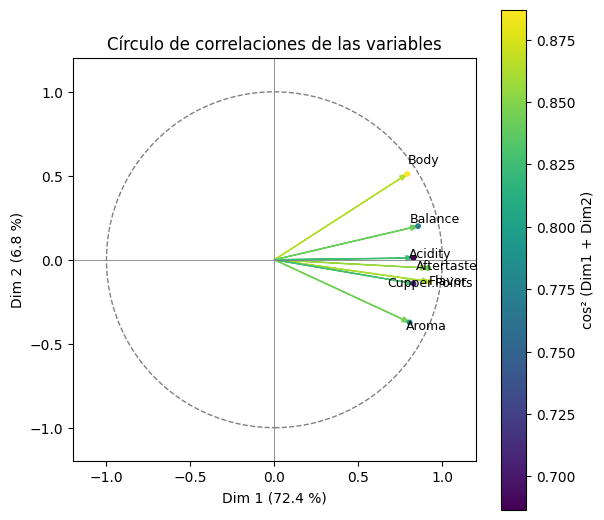

In [43]:
# Círculo de correlaciones: las 7 variables en el plano Dim1-Dim2, coloreadas por su cos²
c2_plano = (cos2['Dim1'] + cos2['Dim2']).values
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='gray', ls='--'))
ax.axhline(0, color='gray', lw=.6); ax.axvline(0, color='gray', lw=.6)
sc = None
for (v, row), q in zip(loadings.iterrows(), c2_plano):
    ax.arrow(0, 0, row['Dim1'], row['Dim2'], head_width=.03, length_includes_head=True,
             color=plt.cm.viridis(q))
    ax.text(row['Dim1'] * 1.12, row['Dim2'] * 1.12, v, ha='center', fontsize=9)
sc = ax.scatter(loadings['Dim1'], loadings['Dim2'], c=c2_plano, cmap='viridis', s=10)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_aspect('equal')
ax.set_xlabel(f"Dim 1 ({var_ratio[0]*100:.1f} %)")
ax.set_ylabel(f"Dim 2 ({var_ratio[1]*100:.1f} %)")
ax.set_title('Círculo de correlaciones de las variables')
plt.colorbar(sc, label='cos² (Dim1 + Dim2)')
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / 'pca_circulo_variables.png', bbox_inches='tight', dpi=150)
plt.show()

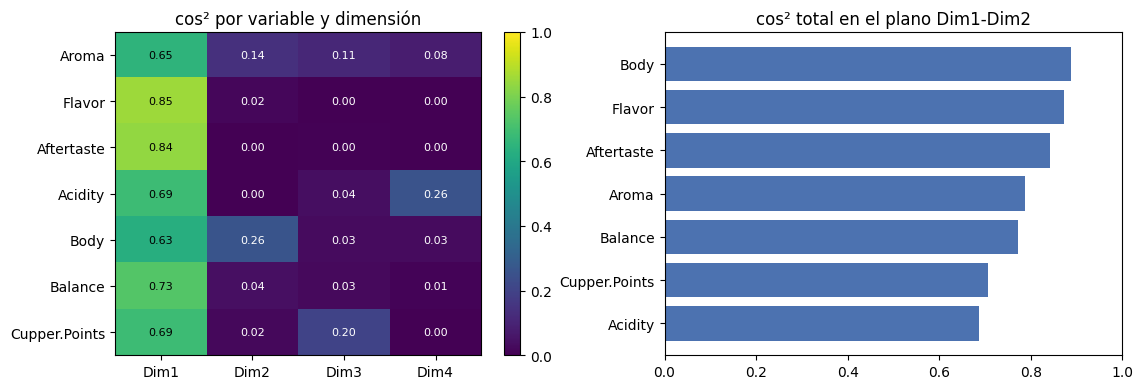

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
im = ax[0].imshow(cos2.iloc[:, :4], cmap='viridis', aspect='auto', vmin=0, vmax=1)
ax[0].set_xticks(range(4), dims[:4]); ax[0].set_yticks(range(len(FEATS)), FEATS)
for i in range(len(FEATS)):
    for j in range(4):
        ax[0].text(j, i, f'{cos2.iloc[i, j]:.2f}', ha='center', va='center',
                   color='white' if cos2.iloc[i, j] < .5 else 'black', fontsize=8)
ax[0].set_title('cos² por variable y dimensión'); fig.colorbar(im, ax=ax[0])

c2p = (cos2['Dim1'] + cos2['Dim2']).sort_values()
ax[1].barh(c2p.index, c2p.values, color='#4c72b0')
ax[1].set_xlim(0, 1); ax[1].set_title('cos² total en el plano Dim1-Dim2')
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / 'pca_cos2.png', bbox_inches='tight', dpi=150)
plt.show()

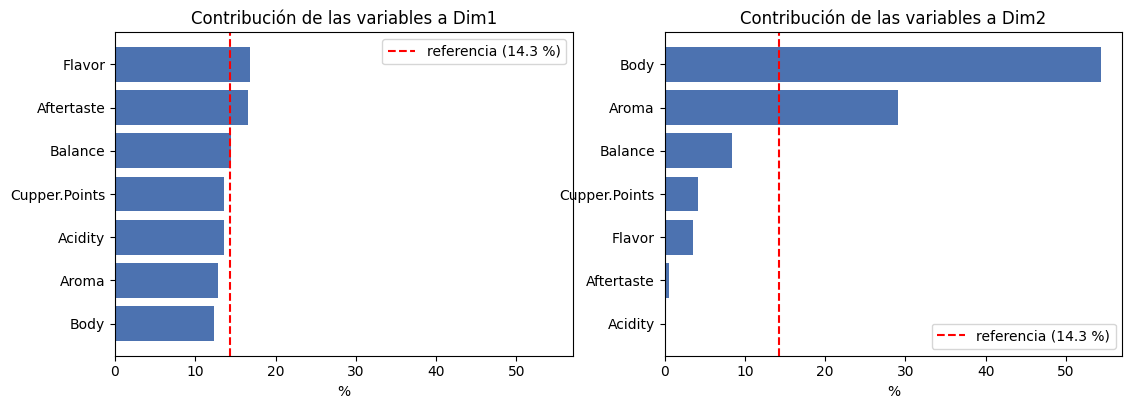

In [45]:
# Contribución de cada variable a Dim1 y a Dim2 (con la línea de referencia = 100 / n)
ref = 100 / len(FEATS)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
for a, d in zip(ax, ['Dim1', 'Dim2']):
    s = contrib[d].sort_values()
    a.barh(s.index, s.values, color='#4c72b0')
    a.axvline(ref, ls='--', color='red', label=f'referencia ({ref:.1f} %)')
    a.set_title(f'Contribución de las variables a {d}'); a.set_xlabel('%'); a.legend()
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / 'pca_contribuciones.png', bbox_inches='tight', dpi=150)
plt.show()

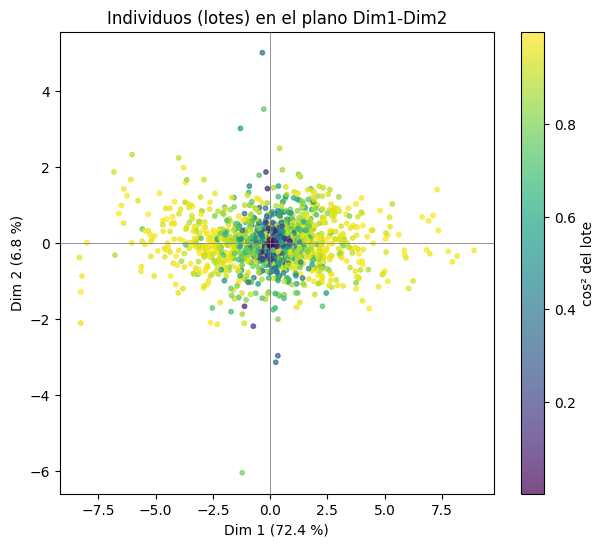

In [46]:
# Individuos (lotes) en el plano Dim1-Dim2, coloreados por su cos² en ese plano
ind = PCA(n_components=n_90, random_state=SEED).fit_transform(X)
ind_cos2 = (ind[:, 0] ** 2 + ind[:, 1] ** 2) / (ind ** 2).sum(axis=1)
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(ind[:, 0], ind[:, 1], c=ind_cos2, cmap='viridis', s=10, alpha=.7)
ax.axhline(0, color='gray', lw=.6); ax.axvline(0, color='gray', lw=.6)
ax.set_xlabel(f"Dim 1 ({var_ratio[0]*100:.1f} %)")
ax.set_ylabel(f"Dim 2 ({var_ratio[1]*100:.1f} %)")
ax.set_title('Individuos (lotes) en el plano Dim1-Dim2')
plt.colorbar(sc, label='cos² del lote')
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / 'pca_individuos.png', bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** Dim 1, que concentra cerca del 72 % de la varianza, recoge casi toda la información: los siete atributos cargan fuerte y en la misma dirección positiva (entre 0.79 y 0.92) y contribuyen casi por igual, entre el 12 % y el 17 % cada uno. En la práctica es un eje de calidad general de la taza: un lote con Dim 1 alto puntuó alto en todos los atributos.

Dim 2, en cambio, apenas explica un 7 % adicional y contrasta a `Body` (contribuye cerca del 54 %, hacia el lado positivo) con `Aroma` (cerca del 29 %, hacia el lado negativo), mientras el resto de los atributos casi no participa. Este eje separa cafés de cuerpo marcado de cafés más aromáticos, aunque su peso es mucho menor que el de Dim 1.

Para llegar al 90 % de varianza acumulada hacen falta 4 componentes, aunque ya con las dos primeras dimensiones se recogen los dos contrastes más claros entre los lotes: la calidad general y el contraste entre cuerpo y aroma. Si esas dos dimensiones bastan para separar bien a los lotes, o si de verdad se necesita el 90 % de la varianza, es algo que no se puede decidir solo mirando el peso de las variables: se define comparando el desempeño del clustering. Por eso, en las siguientes secciones se prueban tres representaciones (los 7 atributos originales, `pca_2` y `pca_4`) y se elige la que mejor separe a los lotes según las métricas internas definidas anteriormente.

## 4.5 Búsqueda: representación × algoritmo × número de grupos

Se prueba cada combinación de:
- **representación:** los **7 atributos** estandarizados, **`pca_2`** (las 2 primeras dimensiones, ~79 % de la varianza) o **`pca_4`** (~90 %),
- **algoritmo:** k-means, aglomerativo, *gaussian mixture*,
- **`k`:** de 2 a 10,

y se guardan sus tres métricas internas. 

In [47]:
def ajustar(algo, k, M):
    if algo == 'kmeans':
        return KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(M)
    if algo == 'agglomerative':
        return AgglomerativeClustering(n_clusters=k).fit_predict(M)
    if algo == 'gaussian_mixture':
        return GaussianMixture(n_components=k, random_state=SEED).fit_predict(M)
    raise ValueError(algo)

representaciones = {
    '7_atributos': X.to_numpy(),
    'pca_2': PCA(n_components=2, random_state=SEED).fit_transform(X),
    'pca_4': PCA(n_components=4, random_state=SEED).fit_transform(X),
}
filas = []
for rep_nombre, M in representaciones.items():
    for algo in ALGOS:
        for k in range(K_MIN, K_MAX + 1):
            etq = ajustar(algo, k, M)
            filas.append({
                'representacion': rep_nombre, 'algoritmo': algo, 'k': k,
                'silhouette': round(silhouette_score(M, etq), 3),
                'davies_bouldin': round(davies_bouldin_score(M, etq), 3),
                'calinski_harabasz': round(calinski_harabasz_score(M, etq), 0),
            })
comparacion = pd.DataFrame(filas)
comparacion.sort_values('silhouette', ascending=False).head(12)

,representacion,algoritmo,k,silhouette,davies_bouldin,calinski_harabasz
36,pca_2,agglomerative,2,0.465,0.718,1154.0
27,pca_2,kmeans,2,0.458,0.765,1434.0
28,pca_2,kmeans,3,0.428,0.761,1506.0
46,pca_2,gaussian_mixture,3,0.416,0.703,1244.0
29,pca_2,kmeans,4,0.398,0.771,1497.0
45,pca_2,gaussian_mixture,2,0.392,8.677,12.0
54,pca_4,kmeans,2,0.391,0.912,1106.0
37,pca_2,agglomerative,3,0.386,0.808,1357.0
30,pca_2,kmeans,5,0.379,0.792,1500.0
38,pca_2,agglomerative,4,0.378,0.745,1199.0


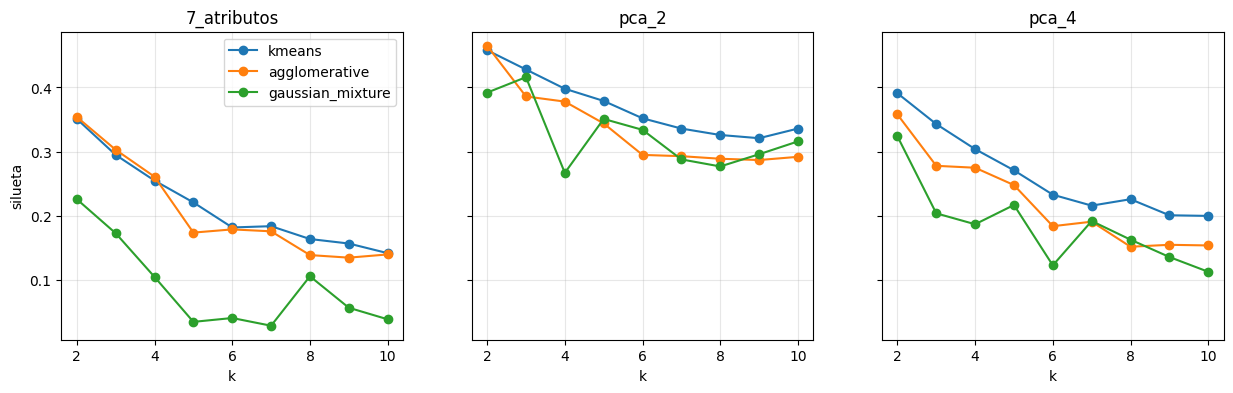

Mejor combinación por silueta:
representacion               pca_2
algoritmo            agglomerative
k                                2
silhouette                   0.465
davies_bouldin               0.718
calinski_harabasz           1154.0
Name: 36, dtype: object


In [48]:
# Curvas de silueta vs k, un panel por representación
fig, axes = plt.subplots(1, len(representaciones), figsize=(15, 4), sharey=True)
for ax, rep_nombre in zip(np.atleast_1d(axes), representaciones):
    sub = comparacion[comparacion['representacion'] == rep_nombre]
    for algo in ALGOS:
        s = sub[sub['algoritmo'] == algo]
        ax.plot(s['k'], s['silhouette'], 'o-', label=algo)
    ax.set_title(rep_nombre); ax.set_xlabel('k'); ax.grid(alpha=.3)
np.atleast_1d(axes)[0].set_ylabel('silueta'); np.atleast_1d(axes)[0].legend()
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / 'silueta_vs_k.png',
            bbox_inches='tight', dpi=150)
plt.show()

mejor = comparacion.loc[comparacion['silhouette'].idxmax()]
print('Mejor combinación por silueta:')
print(mejor)

**Hallazgo.** La representación `pca_2` domina la comparación completa: sus mejores combinaciones superan a todas las de `pca_4` y a las de los 7 atributos originales, lo que confirma que las dos primeras dimensiones concentran la señal útil, mientras las otras suman poco.

Dentro de `pca_2`, la combinación con mayor silueta de toda la corrida es en realidad el aglomerativo con `k=2` (0.465), apenas por encima de k-means con `k=2` (0.458), una diferencia de 0.007 que no alcanza para preferirlo. El aglomerativo, además, es más costoso de calcular a este tamaño de datos. Por eso se elige `kmeans`, que da un resultado casi idéntico, es más simple, reproducible y permite clasificar lotes nuevos con el modelo ya ajustado.

Sobre el número de grupos, la silueta es más alta en `k=2` (0.458) que en `k=3` (0.428), pero esto era esperable: como los 7 atributos están muy correlacionados y casi toda la variación cabe en un eje de la dimensión 1, la silueta tiende a maximizarse partiendo ese eje en dos, "mejor" y "peor" café, algo que aporta poco frente a lo que ya dice `Total.Cup.Points >= 80` y no sirve al objetivo de encontrar varios perfiles de calidad. La caída de `k=2` a `k=3` tampoco es unánime entre las métricas: Davies-Bouldin mejora levemente (0.761 frente a 0.765) y Calinski-Harabasz también (1506 frente a 1434). Por eso se prefiere `k=3`, que reparte los 1 310 lotes en tres grupos (708, 295 y 307) con perfiles más útiles para el dashboard. `k=4` (0.398) ya pierde más y no se justifica frente a lo que ganaría en detalle.

## 4.6 Modelo final

In [49]:
# Elección de 4.5: pca_2 + kmeans; k=3.
REPRESENTACION = 'pca_2'      # '7_atributos' | 'pca_2' | 'pca_4'
ALGORITMO      = 'kmeans'
K_FINAL        = 3          

M_final = representaciones[REPRESENTACION]
if ALGORITMO == 'kmeans':
    modelo = KMeans(n_clusters=K_FINAL, n_init=10, random_state=SEED).fit(M_final)
    etiquetas = modelo.labels_
elif ALGORITMO == 'agglomerative':
    modelo = AgglomerativeClustering(n_clusters=K_FINAL).fit(M_final)
    etiquetas = modelo.labels_
else:
    modelo = GaussianMixture(n_components=K_FINAL, random_state=SEED).fit(M_final)
    etiquetas = modelo.predict(M_final)

print('Silueta del modelo final:', round(silhouette_score(M_final, etiquetas), 3))
print('Tamaño de cada grupo:')
print(pd.Series(etiquetas).value_counts().sort_index())

Silueta del modelo final: 0.428
Tamaño de cada grupo:
0    708
1    295
2    307
Name: count, dtype: int64


       media  minimo    p25  pct_negativa    n
grupo                                         
0      0.452   0.011  0.330           0.0  708
1      0.422  -0.016  0.315           1.0  295
2      0.379  -0.016  0.274           1.6  307


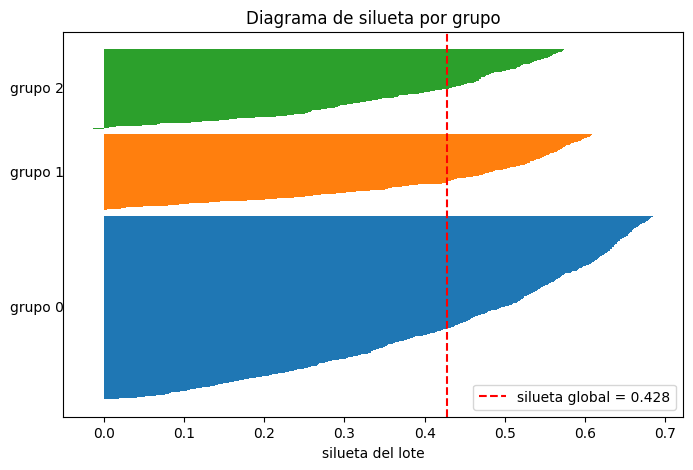

In [50]:
# Diagnóstico de la silueta por grupo
sil = silhouette_samples(M_final, etiquetas)
diag = (pd.DataFrame({'grupo': etiquetas, 'silueta': sil})
        .groupby('grupo')['silueta']
        .agg(media='mean', minimo='min',
             p25=lambda s: s.quantile(0.25),
             pct_negativa=lambda s: round((s < 0).mean() * 100, 1),
             n='count')
        .round(3))
print(diag)

# Diagrama de silueta: una barra por lote, ordenadas dentro de cada grupo
fig, ax = plt.subplots(figsize=(8, 5))
y = 0
for g in sorted(set(etiquetas)):
    vals = np.sort(sil[etiquetas == g])
    ax.barh(range(y, y + len(vals)), vals, height=1)
    ax.text(-0.05, y + len(vals) / 2, f'grupo {g}', va='center', ha='right')
    y += len(vals) + 20
ax.axvline(silhouette_score(M_final, etiquetas), color='red', ls='--',
           label=f'silueta global = {silhouette_score(M_final, etiquetas):.3f}')
ax.set_xlabel('silueta del lote'); ax.set_yticks([]); ax.legend()
ax.set_title('Diagrama de silueta por grupo')
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / 'silueta_por_grupo.png',
            bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** El modelo final separó los 1310 lotes en tres grupos de un tamaño razonable: 708, 295 y 307 lotes. Qué tan bien definidos quedan esos grupos se mide con la silueta, un número entre -1 y 1 donde, entre más alto, más separados están los grupos entre sí. Aquí dio 0.428 en general, y por grupo 0.45, 0.42 y 0.38: valores que indican una separación moderada, ni muy marcada ni muy débil. Esto coincide con lo que ya se había visto en el PCA: casi toda la variación entre los lotes se concentra en un solo eje, el de calidad general, así que no hay demasiado margen para que los grupos queden completamente aislados unos de otros.

Ningún grupo quedó mal definido. Muy pocos lotes, apenas un 0 %, un 1 % y un 1.6 % según el grupo (menos de 10 lotes en total), tienen una silueta negativa, que es la señal de que un lote encajaría mejor en otro grupo, y aun esos casos están casi en cero, no son errores marcados. El grupo 2 es el que queda un poco menos separado de su vecino (silueta promedio de 0.38), algo que vale la pena tener en cuenta al describirlo en las siguientes fases.

## 4.7 Visualización de los grupos

Proyección de los 1310 lotes a 2 dimensiones, coloreados por grupo para ver si el agrupamiento tiene sentido visual.

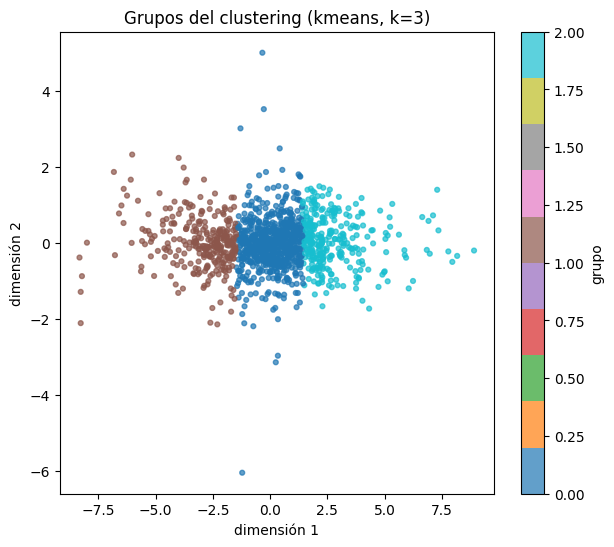

In [54]:
proj = PCA(n_components=2, random_state=SEED).fit_transform(X)
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(proj[:, 0], proj[:, 1], c=etiquetas, cmap='tab10', s=12, alpha=.7)
ax.set_xlabel('dimensión 1'); ax.set_ylabel('dimensión 2')
ax.set_title(f'Grupos del clustering ({ALGORITMO}, k={K_FINAL})')
plt.colorbar(sc, label='grupo')
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / 'grupos_proyeccion_2d.png',
            bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** En la proyección los tres grupos se ordenan a lo largo de la dimensión 1 y no en la dimensión 2. El grupo 1 ocupa la zona baja del eje (centro en −3.0), el grupo 0 la zona media (centro en 0.1) y el grupo 2 la zona alta (centro en 2.8); sobre  la dimensión 2 los tres grupos comparten el mismo centro (alrededor de 0) y la misma dispersión, así que ese eje no los distingue. 

Las fronteras entre tramos son claras pero no hay un hueco vacío entre grupos: el solape ocurre solo en los bordes, donde unos pocos lotes de un grupo alcanzan el arranque del siguiente.

**Nota.** Que la separación visible esté casi toda en un solo eje confirma lo visto en las secciones 4.4 y 4.6: la variación sensorial útil es casi unidimensional. La lectura correcta de los grupos es «niveles de calidad de la taza», y el aporte de la fase 06 será describir qué distingue a cada nivel por origen y manejo (país, altitud, variedad, procesamiento), ya que esa diferencia no está en el espacio sensorial.

## 4.8 Guardado de artefactos

In [52]:
import joblib

models_dir = resolve_path(config['paths']['models_dir']); models_dir.mkdir(exist_ok=True)
tables_dir = resolve_path(config['paths']['reports']['tables_dir']); tables_dir.mkdir(exist_ok=True)

# 1) modelo ajustado
joblib.dump(modelo, models_dir / 'clustering_model.joblib')

# 2) dataset limpio + etiqueta de grupo
coffee_clustered = coffee.copy()
coffee_clustered['grupo'] = etiquetas
coffee_clustered.to_csv(processed / 'coffee_clustered.csv', index=False)

# 3) tabla comparativa completa (todas las combinaciones probadas)
comparacion.to_csv(tables_dir / 'clustering_comparison.csv', index=False)

# 4) metadatos del modelo elegido
meta = {
    'representacion': REPRESENTACION, 'algoritmo': ALGORITMO, 'k': int(K_FINAL),
    'random_seed': SEED, 'n_lotes': int(len(etiquetas)),
    'silhouette': float(round(silhouette_score(M_final, etiquetas), 4)),
    'davies_bouldin': float(round(davies_bouldin_score(M_final, etiquetas), 4)),
    'calinski_harabasz': float(round(calinski_harabasz_score(M_final, etiquetas), 1)),
    'tam_grupos': pd.Series(etiquetas).value_counts().sort_index().to_dict(),
}
(models_dir / 'clustering_metadata.json').write_text(json.dumps(meta, indent=2), encoding='utf-8')
print(json.dumps(meta, indent=2))

{
  "representacion": "pca_2",
  "algoritmo": "kmeans",
  "k": 3,
  "random_seed": 42,
  "n_lotes": 1310,
  "silhouette": 0.4279,
  "davies_bouldin": 0.7608,
  "calinski_harabasz": 1505.9,
  "tam_grupos": {
    "0": 708,
    "1": 295,
    "2": 307
  }
}


## 4.9 Qué se debe hacer en las fases siguientes

De esta fase salen el modelo ya entrenado, un archivo con el grupo asignado a cada lote y una tabla con todas las combinaciones que se probaron. A partir de esto, esto es lo que falta por hacer en las próximas fases.

### Evaluación

| Tarea | Detalle |
|---|---|
| Validación interna | Reportar de nuevo las métricas usadas para comparar los grupos (silueta, Davies-Bouldin y Calinski-Harabasz), y un gráfico que muestre si algún lote quedó mal ubicado dentro de su grupo. |
| Estabilidad | Repetir el agrupamiento varias veces, cambiando la semilla y usando solo el 80 % de los lotes cada vez, para ver qué tanto cambian los grupos de una corrida a otra (esto se mide con el índice ARI). Si cambian mucho, no se puede confiar en ellos. |
| Contraste externo | Comparar los grupos con la forma tradicional de medir calidad, es decir, si el lote supera los 80 puntos o no, para ver si el clustering encontró lo mismo que ya se sabía o algo distinto. |
| Criterios de éxito | Comprobar si los resultados cumplen con lo que se definió como éxito desde el inicio del proyecto, en la fase 01. |

### Interpretación

| Tarea | Detalle |
|---|---|
| Perfilar por origen y manejo | Ver qué tan comunes son ciertos países, variedades, métodos de procesamiento y colores de grano en cada grupo, para encontrar patrones. |
| Perfilar por altitud, humedad y cosecha | Comparar estos datos entre los grupos, usando solo los lotes que sí los tienen registrados. |
| Perfilar por defectos | Comparar entre grupos qué tantos defectos y granos inmaduros (*quakers*) tiene cada uno. |
| Cautelas al interpretar | Tener en cuenta que hay países con muy pocos lotes, que la base de datos solo incluye cafés que buscan una certificación de calidad (no representa a todo el café que existe), y que el café robusta no quedó incluido en este análisis. |
| Dashboard | Exportar una tabla con el grupo de cada lote y sus características, lista para usarse en Power BI o Tableau. |